# deskbird Growth Analysis — Condensed

A leaner companion to the full analysis notebook (`deskbird_growth_analysis.ipynb`, 190 cells) — same data, same conclusions, same numbers, but trimmed to what a reviewer needs to verify the work is real and understand the reasoning quickly. Where a section is cut down, a link points to the exact place in the full notebook to see the complete validation, code, and caveats.


## Table of Contents

- 1. Setup
- 2. Data Overview
- 3. Data Quality — Key Checks
- 4. Build the Cleaned, Joined Dataset
- 5. The 5 Metrics
- 6. Exploratory Insights
- 7. Advanced Analysis (pointer only)
- 8. Data Model
- 9. Recommendations

*Plain outline, not clickable — see VS Code's Outline panel (Ctrl+Shift+O) for navigation.*


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [2]:
crm_pipeline = pd.read_csv('C:/Users/Mohamad/Desktop/DeskBird Case/crm_pipeline.csv', encoding='latin-1')
paid_ads = pd.read_csv('C:/Users/Mohamad/Desktop/DeskBird Case/paid_ads.csv', encoding='latin-1')
product_usage_events = pd.read_csv('C:/Users/Mohamad/Desktop/DeskBird Case/product_usage_events.csv', encoding='latin-1')

date_cols = ['created_at', 'opportunity_created_at', 'close_date', 'trial_start_at', 'trial_end_at']
crm_pipeline[date_cols] = crm_pipeline[date_cols].apply(pd.to_datetime)
paid_ads['date'] = pd.to_datetime(paid_ads.date)
product_usage_events['event_time'] = pd.to_datetime(product_usage_events.event_time)

## 2. Data Overview

Three fictional raw datasets: paid ads (impressions/clicks/spend), CRM pipeline (leads → opportunities → closed won/lost), and product usage events (logins, seats, feature adoption). Heads below; full `.shape`/`.dtypes`/`.describe()` walkthrough is in the full notebook's §2.

In [3]:
crm_pipeline.head()

,lead_id,created_at,email_domain,company_id,company_name,campaign_id,utm_campaign,lifecycle_stage,opportunity_id,opportunity_created_at,amount,close_date,close_status,trial_start_at,trial_end_at
0,LEAD_0001,2025-02-18,hoolidynamics.com,ACC_0001,Hooli Dynamics,CMP_1016,camp_16,Closed Lost,OPP_0001,2025-02-25,31776.0,2025-03-28,Lost,2025-02-23,2025-03-09
1,LEAD_0002,2025-08-16,wayneindustries.com,ACC_0002,Wayne Industries,CMP_1006,camp_6,Closed Lost,OPP_0002,2025-08-23,4726.0,2025-12-01,Lost,2025-08-16,2025-08-30
2,LEAD_0003,2025-04-18,umbrelladynamics.com,ACC_0003,Umbrella Dynamics,CMP_1015,camp_15,MQL,NaN,NaT,NaN,NaT,NaN,NaT,NaT
3,LEAD_0004,2025-04-23,globexenterprises.com,ACC_0004,Globex Enterprises,CMP_1009,camp_9,Closed Lost,OPP_0004,2025-05-26,26723.0,2025-05-28,Lost,NaT,NaT
4,LEAD_0005,2025-02-05,acmeenterprises.com,ACC_0005,Acme Enterprises,CMP_1003,camp_3,MQL,NaN,NaT,NaN,NaT,NaN,2025-02-12,2025-02-26


In [4]:
paid_ads.head()

,date,campaign_id,campaign_name,channel,utm_source,utm_medium,utm_campaign,impressions,clicks,cost
0,2025-01-01,CMP_1001,EMEA_FeatureY_Search,Paid Social,linkedin,paid_social,camp_1,2948,61,482.13
1,2025-01-01,CMP_1002,APAC_Brand_Search,Paid Social,linkedin,paid_social,camp_2,4198,74,384.27
2,2025-01-01,CMP_1003,APAC_FeatureY_Search,Paid Search,google,paid_search,camp_3,7491,204,841.97
3,2025-01-01,CMP_1004,US_FeatureY_Display,Paid Social,linkedin,paid_social,camp_4,3216,71,341.43
4,2025-01-01,CMP_1005,US_FeatureX_Search,Paid Social,linkedin,paid_social,camp_5,4144,77,394.94


In [5]:
product_usage_events.head()

,event_time,company_id,user_id,event_type,plan_tier,seats_used
0,2025-02-23 08:06:00,ACC_0001,USR_0001_006,seat_added,starter,69
1,2025-02-24 22:56:00,ACC_0001,USR_0001_009,invite_sent,starter,14
2,2025-02-24 03:53:00,ACC_0001,USR_0001_014,feature_y_used,enterprise,55
3,2025-02-25 12:15:00,ACC_0001,USR_0001_010,login,trial,45
4,2025-02-25 23:46:00,ACC_0001,USR_0001_025,login,starter,43


**Consequential observations** (the ones that actually shape what follows, not every `describe()` stat):
- CRM: 500 leads, but only 120 unique `company_name`s vs. 500 unique `company_id`s — the identity-resolution issue that Section 3 digs into and that changes every downstream rate.
- CRM: only 162 of 500 leads (32%) ever reach an opportunity (91 Lost, 71 Won at lead-grain).
- Paid Ads: 5,187 rows, 19 campaigns across 3 channels (`Paid Social`, `Display`, `Paid Search`), spanning ~9 months (Jan–Sep 2025).
- Usage: 33,498 events, but only 311 of the 500 leads' accounts have any usage data at all — a population gap explained in Section 3.
- Usage: trial length is a fixed **14 days**, zero exceptions, across all 311 trials — a hard constraint, not a rough average.

Full observation lists (dtype quirks, describe() ranges, minor caveats): full notebook §2.

## 3. Data Quality — Key Checks

The full notebook runs 8 systematic checks before trusting any join (§3, "Verifying Assumptions"). The 4 below are the ones that are actually consequential — they change a metric, justify a modeling choice, or gate what a downstream number is allowed to claim. The other 4 (branch-hypothesis discarded, unattributed leads bucketed not dropped, chronological-ordering edge cases, 14-day trial length reconfirmed at company grain) are summarized in the table after, with zero re-derivation — full checks and code: full notebook §3.

### Finding 1 — `company_name` is the true account key, not `company_id`

In [6]:
print('lead_id unique:', crm_pipeline.lead_id.nunique(), '/ rows:', len(crm_pipeline))
print('company_id unique:', crm_pipeline.company_id.nunique())
print('company_name unique:', crm_pipeline.company_name.nunique())

ids_per_company = crm_pipeline.groupby('company_name').company_id.nunique()
print()
print('distribution of company_ids per company_name:')
print(ids_per_company.value_counts().sort_index())

lead_id unique: 500 / rows: 500
company_id unique: 500
company_name unique: 120

distribution of company_ids per company_name:
company_id
1      8
2     20
3     24
4     17
5     21
6     16
7      7
8      3
9      2
10     2
Name: count, dtype: int64


**Conclusion:** `company_id` is 1:1 with `lead_id` (lead-grain, not account-grain) — 500 leads, 500 distinct `company_id`s. Only 120 unique `company_name`s exist across those 500 IDs, so a real company can own 1–10 different `company_id`s. **`company_name` is the only field that represents the real-world account** — every company-level rollup in this notebook (`company_df`, all 5 metrics) is built on it, not `company_id`.

### Finding 2 — Referential integrity is clean, safe as inner joins

In [7]:
orphan_campaigns = set(crm_pipeline.campaign_id.dropna()) - set(paid_ads.campaign_id)
orphan_usage_companies = set(product_usage_events.company_id) - set(crm_pipeline.company_id)

print('CRM campaign_ids missing from paid_ads:', len(orphan_campaigns))
print('Usage company_ids missing from CRM:', len(orphan_usage_companies))
print('CRM company_ids that have usage data:', product_usage_events.company_id.nunique(), 'of', crm_pipeline.company_id.nunique())

CRM campaign_ids missing from paid_ads: 0
Usage company_ids missing from CRM: 0
CRM company_ids that have usage data: 311 of 500


**Conclusion:** zero orphaned keys in either direction — every join in this notebook is a plain inner join, no defensive outer-join/fallback logic needed. Only 311 of 500 CRM `company_id`s have usage data at all, which the next check explains.

### Finding 3 — Usage data exists only for accounts that started a trial, but usage past trial-end is a data quality issue

In [8]:
trial_ids = set(crm_pipeline[crm_pipeline.trial_start_at.notna()].company_id)
usage_ids = set(product_usage_events.company_id)
print('Accounts with usage data == accounts with a trial_start_at?', trial_ids == usage_ids)

# post-trial usage check, done at the CORRECT grain (company_name, not lead-grain company_id -- Finding 1)
stage_rank_map_f3 = {'Lead': 0, 'MQL': 1, 'SQL': 2, 'Closed Lost': 3, 'Closed Won': 4}
peak_rank_f3 = crm_pipeline.assign(stage_rank=crm_pipeline.lifecycle_stage.map(stage_rank_map_f3)).groupby('company_name').stage_rank.max()
outcome_f3 = peak_rank_f3.map({0: 'Open', 1: 'Open', 2: 'Open', 3: 'Closed Lost', 4: 'Closed Won'})

id_to_name_f3 = crm_pipeline[['company_id', 'company_name']].drop_duplicates()
usage_named_f3 = product_usage_events.merge(id_to_name_f3, on='company_id')
last_event_co = usage_named_f3.groupby('company_name').event_time.max()
trial_end_co = crm_pipeline.groupby('company_name').trial_end_at.max()

merged_f3 = pd.concat([last_event_co.rename('last_event'), trial_end_co, outcome_f3.rename('outcome')], axis=1).dropna(subset=['last_event', 'trial_end_at'])
after_trial_f3 = merged_f3[merged_f3.last_event > merged_f3.trial_end_at]
print(f'Companies (company_name-grain) with post-trial usage: {len(after_trial_f3)} of {len(merged_f3)}, by outcome:')
print(after_trial_f3.outcome.value_counts())

# magnitude, not just presence -- how much post-trial activity, by outcome
usage_with_trial_end = usage_named_f3.merge(trial_end_co.rename('trial_end_at'), on='company_name')
post_trial_events = usage_with_trial_end[usage_with_trial_end.event_time > usage_with_trial_end.trial_end_at]
n_by_outcome = post_trial_events.assign(outcome=post_trial_events.company_name.map(outcome_f3)).groupby('outcome').size()
avg_by_outcome = (n_by_outcome / after_trial_f3.outcome.value_counts()).round(1)
print()
print('Average post-trial events per affected company, by outcome:')
print(avg_by_outcome)

Accounts with usage data == accounts with a trial_start_at? True
Companies (company_name-grain) with post-trial usage: 113 of 115, by outcome:
outcome
Closed Won     51
Closed Lost    40
Open           22
Name: count, dtype: int64

Average post-trial events per affected company, by outcome:
outcome
Closed Lost      3.2
Closed Won     212.1
Open             4.0
dtype: float64


**Conclusion:** the set of accounts with usage events is *exactly* the set with a `trial_start_at` — so any trial-engagement analysis has a well-defined population of 311 leads, not all 500. Separately, this notebook originally treated "post-trial usage" as a positive Closed-Won signal — **that claim doesn't hold and is corrected here as a data quality issue instead**: computed at the correct `company_name` grain, 113 of 115 companies (98%) with usage data show *some* activity past `trial_end_at`, regardless of outcome — strictly, non-converted accounts shouldn't generate any usage after their trial closes. But the magnitude clarifies severity: Closed-Won companies average **~212** post-trial events each, versus **~3-4** for Closed-Lost/Open — a ~50-65x gap, not comparable volume. So this is a real but low-impact issue (a handful of trailing events on non-converted accounts, not sustained usage), and doesn't materially undermine Closed-Won's own post-close usage as a retention signal — carried forward as a minor caveat on Metrics 3 and 5, not used as a positive signal. Full showcase and downstream-impact check: full notebook §3.

### Finding 4 — `amount` is a CRM deal-size estimate, not billing revenue

In [9]:
won_leads_caveat = crm_pipeline[crm_pipeline.lifecycle_stage == 'Closed Won'].sort_values('close_date')
company_amount = won_leads_caveat.groupby('company_name').amount.first()

avg_seats = product_usage_events.groupby('company_id').seats_used.mean()
id_to_name_caveat = crm_pipeline[['company_id', 'company_name']].drop_duplicates().set_index('company_id').company_name
company_seats = avg_seats.rename('avg_seats').to_frame().join(id_to_name_caveat).groupby('company_name').avg_seats.mean()

check = pd.DataFrame({'amount': company_amount, 'avg_seats': company_seats}).dropna()
print('Correlation between amount and avg_seats:', round(check.amount.corr(check.avg_seats), 3))

Correlation between amount and avg_seats: 0.073


**Conclusion:** correlation between `amount` and account size (avg seats) is essentially zero (~0.07) — real per-seat pricing would show a clear positive correlation. We treat `amount` as a generic deal-value estimate, not a size-driven contract value. **Implication carried into Metric 3 (LTV):** only Closed-Won `amount` is used, and the resulting LTV:CAC ratio is heavily caveated as directional, not precise unit economics.

### Other findings (summary — full checks in full notebook §3)

| Finding | Conclusion |
|---|---|
| Branch/region hypothesis | Discarded — repeat leads over time from the same real company (shared corporate domain, personal-email contacts), not separate regional entities. |
| Unattributed leads | 33 leads (6.6%) have no `campaign_id` — bucketed as `"Organic/Unattributed"`, not dropped, so paid-channel metrics aren't inflated. |
| Chronological ordering | Holds across all 500 leads except 6 already-known rows (`close_date` before `opportunity_created_at`, synthetic-data edge case, narrowly excluded from 2 derived fields only). |
| Trial length | Confirmed a hard 14-day constraint at both lead and company grain, zero exceptions. |
| `plan_tier` / `seats_used` | Randomly assigned per event, not persistent account state — excluded from any metric; event-count signals (`feature_x/y_used`, `seat_added`, `invite_sent`) remain valid. |

Full data-quality section (8 checks, full code, Assumptions Summary, Caveats): **full notebook §3**.

## 4. Build the Cleaned, Joined Dataset

`company_df` is the single source of truth for company-level analysis — one row per real company (`company_name`), pooling all `company_id`s/`lead_id`s that belong to it, so every later "per company" chart is correct without re-deriving the join each time.

**The grain rule:** company-grain (`company_df`) is used for anything about *outcomes* — win rate, customer count, retention — since that's the real business unit. Lead-grain is kept deliberately where the question is about the lead/cost unit itself — e.g. Cost Per Lead (Metric 4) is intentionally lead-grain, not an inconsistency.

In [10]:
campaign_channel_map = paid_ads[['campaign_id', 'channel']].drop_duplicates().set_index('campaign_id').channel
crm_pipeline['channel'] = crm_pipeline.campaign_id.map(campaign_channel_map).fillna('Organic/Unattributed')

stage_rank_map = {'Lead': 0, 'MQL': 1, 'SQL': 2, 'Closed Lost': 3, 'Closed Won': 4}
crm_pipeline['stage_rank'] = crm_pipeline.lifecycle_stage.map(stage_rank_map)

channel_colors = {'Paid Social': '#0072B2', 'Display': '#009E73', 'Paid Search': '#E69F00', 'Organic/Unattributed': '#999999'}
channel_order = ['Paid Social', 'Display', 'Paid Search', 'Organic/Unattributed']

In [11]:
company_df = crm_pipeline.groupby('company_name').agg(
    company_ids=('company_id', list), lead_ids=('lead_id', list),
    n_leads=('lead_id', 'count'), peak_rank=('stage_rank', 'max'),
).reset_index()

entry_channel = crm_pipeline.sort_values('created_at').groupby('company_name').channel.first()
company_df['entry_channel'] = company_df.company_name.map(entry_channel)

rank_to_outcome = {0: 'Open', 1: 'Open', 2: 'Open', 3: 'Closed Lost', 4: 'Closed Won'}
company_df['outcome'] = company_df.peak_rank.map(rank_to_outcome)

def resolved_info(name, peak_rank):
    if peak_rank < 3:
        return pd.Series({'close_date': pd.NaT, 'amount': np.nan})
    subset = crm_pipeline[crm_pipeline.company_name == name]
    won = subset[subset.lifecycle_stage == 'Closed Won']
    rep = won.sort_values('close_date').iloc[0] if len(won) else subset[subset.lifecycle_stage == 'Closed Lost'].sort_values('close_date').iloc[0]
    return pd.Series({'close_date': rep.close_date, 'amount': rep.amount})

resolved = company_df.apply(lambda r: resolved_info(r.company_name, r.peak_rank), axis=1)
company_df = pd.concat([company_df, resolved], axis=1)

id_to_name_map = crm_pipeline[['company_id', 'company_name']].drop_duplicates()
usage_named = product_usage_events.merge(id_to_name_map, on='company_id')
company_df['total_usage_events'] = company_df.company_name.map(usage_named.groupby('company_name').size()).fillna(0)
company_df['distinct_users'] = company_df.company_name.map(usage_named.groupby('company_name').user_id.nunique()).fillna(0)

trial_windows_all = crm_pipeline[crm_pipeline.trial_start_at.notna()][['company_id', 'trial_start_at', 'trial_end_at']]
u_trial = product_usage_events.merge(trial_windows_all, on='company_id')
in_trial = u_trial[(u_trial.event_time >= u_trial.trial_start_at) & (u_trial.event_time <= u_trial.trial_end_at)]
in_trial_named = in_trial.merge(id_to_name_map, on='company_id')
company_df['trial_engagement_events'] = company_df.company_name.map(in_trial_named.groupby('company_name').size()).fillna(0)

print('company_df shape:', company_df.shape, '(120 real companies)')

company_df shape: (120, 12) (120 real companies)


Full build notes, including the 311-vs-115 identity-resolution bug this fixed: **full notebook §4**.

## 5. The 5 Metrics

The brief asks us to *define* 5 growth metrics with rationale, not exhaustively explore them — full derivations, alternate cuts, and every caveat are in the full notebook's §5. Here: one definition, one chart, one number each.

### Metric 1: CAC — Blended + by Channel
Definition: total channel spend ÷ Closed-Won companies attributed to that channel (earliest-winning-lead attribution).

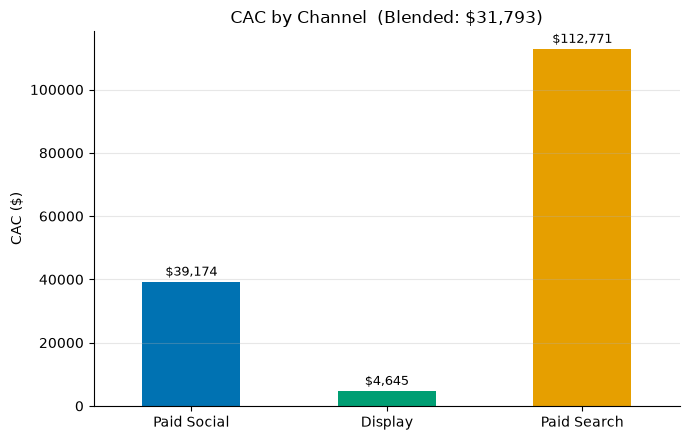

In [12]:
channel_order_cac = ['Paid Social', 'Display', 'Paid Search', 'Organic/Unattributed']
paid_channel_order = ['Paid Social', 'Display', 'Paid Search']

campaign_channel_cac = paid_ads[['campaign_id', 'channel']].drop_duplicates().set_index('campaign_id').channel
crm_channel_cac = crm_pipeline.campaign_id.map(campaign_channel_cac).fillna('Organic/Unattributed')

won_leads_cac = crm_pipeline[crm_pipeline.lifecycle_stage == 'Closed Won'].copy()
won_leads_cac['channel'] = crm_channel_cac.loc[won_leads_cac.index]
earliest_won_cac = won_leads_cac.sort_values('close_date').groupby('company_name').first()

won_by_channel_cac = earliest_won_cac.channel.value_counts().reindex(channel_order_cac).fillna(0)
spend_by_channel_cac = paid_ads.groupby('channel').cost.sum().reindex(paid_channel_order)
cac_by_channel = (spend_by_channel_cac / won_by_channel_cac.reindex(paid_channel_order)).round(0)

blended_cac_paid_only = round(paid_ads.cost.sum() / won_by_channel_cac.reindex(paid_channel_order).sum(), 0)

fig, ax = plt.subplots(figsize=(7, 4.5))
cac_by_channel.plot(kind='bar', ax=ax, color=[channel_colors[c] for c in paid_channel_order])
ax.set_title(f'CAC by Channel  (Blended: ${blended_cac_paid_only:,.0f})')
ax.set_ylabel('CAC ($)'); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=0)
ax.spines[['top', 'right']].set_visible(False); ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(cac_by_channel): ax.text(i, v + 2000, f'${v:,.0f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

**Conclusion:** `Display` is cheapest at $4,645/customer; `Paid Search` is most expensive at $112,771 (best CTR, but thin win volume). Blended CAC (paid-attributed wins): **$31,793**. `Display`'s numbers carry a last-touch-attribution caveat — see §6.

### Metric 2: Funnel Conversion Rate
Definition: company-grain win rate — Closed-Won companies ÷ all companies ever engaged (identity-resolved to 120, not the raw 500 leads).

In [13]:
peak_rank = crm_pipeline.groupby('company_name').stage_rank.max()
n_leads = len(crm_pipeline); n_companies = len(peak_rank)
reached_mql = (peak_rank >= 1).sum(); reached_sql = (peak_rank >= 2).sum()
closed_won = (peak_rank == 4).sum(); closed_lost = (peak_rank == 3).sum()
stalled_lead = (peak_rank == 0).sum(); stalled_mql = (peak_rank == 1).sum(); stalled_sql = (peak_rank == 2).sum()
overall_win_rate = closed_won / n_companies * 100

labels = [f'{n_leads} Raw Leads', f'{n_companies} Unique Companies\n(Identity Resolved)', 'Reached MQL', 'Reached SQL',
          'Closed Won', 'Closed Lost', 'Stalled at Lead', 'Stalled at MQL', 'Stalled at SQL']
node_colors = ['#B0C4DE', '#8E44AD', '#5B9BD5', '#2E5F8A', '#2E7D32', '#C62828', '#B0B7BF', '#B0B7BF', '#B0B7BF']

fig = go.Figure(go.Sankey(
    node=dict(label=labels, color=node_colors, pad=20, thickness=18),
    link=dict(source=[0, 1, 1, 2, 2, 3, 3, 3], target=[1, 2, 6, 3, 7, 4, 5, 8],
              value=[n_companies, reached_mql, stalled_lead, reached_sql, stalled_mql, closed_won, closed_lost, stalled_sql],
              color=['rgba(142,68,173,0.35)', 'rgba(91,155,213,0.4)', 'rgba(176,183,191,0.4)', 'rgba(91,155,213,0.4)',
                     'rgba(176,183,191,0.4)', 'rgba(46,125,50,0.4)', 'rgba(198,40,40,0.4)', 'rgba(176,183,191,0.4)']),
))
fig.update_layout(title_text='Company Funnel: Lead → Identity Resolution → MQL → SQL → Closed Won/Lost', font_size=12, height=520, margin=dict(t=140))
fig.add_annotation(text=f'<b>Overall Win Rate: {closed_won} / {n_companies} companies = {overall_win_rate:.1f}%</b>',
                    xref='paper', yref='paper', x=0.5, y=1.16, showarrow=False, font=dict(size=18, color='#2E7D32'))
fig.show()

**Conclusion: 43.3% overall win rate (52/120 companies).** Alternate cut, resolved-deals-only (Won ÷ (Won+Lost)): 55.3%. Both are correct, they answer different questions — see §6 for why 26 of these companies are more precisely "dormant" than "in-flight."

### Metric 3: LTV:CAC by Channel
Definition: approximate LTV (Closed-Won `amount` × an approximated customer lifetime from cohort retention) ÷ CAC. **Heavily caveated**: lifetime is derived from ~1 year of mostly-censored cohort data using a constant-churn assumption — directional, not precise. Chosen deliberately over a simpler win-rate ratio to demonstrate LTV modeling.

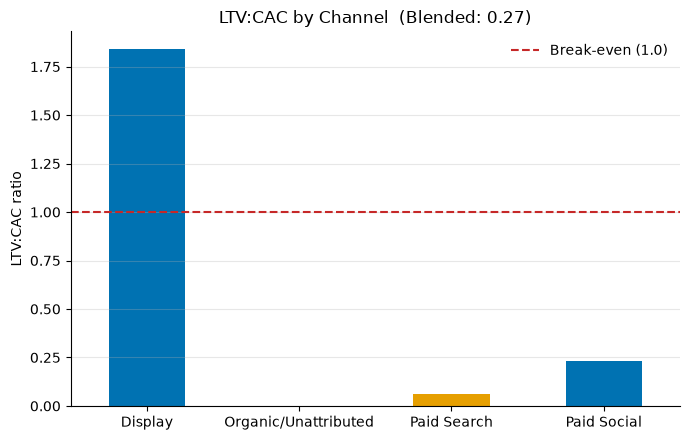

In [14]:
won_ltv = crm_pipeline[crm_pipeline.lifecycle_stage == 'Closed Won'].copy()
company_won_ltv = won_ltv.groupby('company_name').agg(close_date=('close_date', 'min'), company_ids=('company_id', list)).reset_index()
company_won_ltv['close_quarter'] = company_won_ltv.close_date.dt.to_period('Q')
cohort_sizes_ltv = company_won_ltv.groupby('close_quarter').company_name.nunique()

id_to_company_ltv = company_won_ltv.explode('company_ids').rename(columns={'company_ids': 'company_id'})[['company_id', 'company_name', 'close_quarter']]
usage_won_ltv = product_usage_events.merge(id_to_company_ltv, on='company_id')
usage_won_ltv['event_quarter'] = usage_won_ltv.event_time.dt.to_period('Q')
usage_won_ltv['period_number'] = usage_won_ltv.event_quarter.astype('int64') - usage_won_ltv.close_quarter.astype('int64')

active_ltv = usage_won_ltv.groupby(['close_quarter', 'period_number']).company_name.nunique().unstack()
retention_ltv = active_ltv.div(cohort_sizes_ltv, axis=0)
period1_retention = retention_ltv[1].dropna()
period1_retention_clean = period1_retention[~period1_retention.index.astype(str).isin(['2025Q4', '2026Q1'])]

avg_q1_retention = period1_retention_clean.mean()
implied_quarterly_churn = 1 - avg_q1_retention
expected_lifetime_years = (1 / implied_quarterly_churn) / 4

won_amounts = company_df[company_df.outcome == 'Closed Won'].set_index('company_name').amount
channel_by_company = earliest_won_cac.channel
avg_acv_by_channel = won_amounts.groupby(channel_by_company.reindex(won_amounts.index)).mean()
ltv_by_channel = (avg_acv_by_channel * expected_lifetime_years).round(0)
ltv_cac_by_channel = (ltv_by_channel / cac_by_channel).round(2)
blended_ltv_cac = round((won_amounts.mean() * expected_lifetime_years) / blended_cac_paid_only, 2)

fig, ax = plt.subplots(figsize=(7, 4.5))
ltv_cac_by_channel.plot(kind='bar', ax=ax, color=[channel_colors[c] for c in paid_channel_order])
ax.axhline(1.0, color='#C62828', linestyle='--', linewidth=1.5, label='Break-even (1.0)')
ax.set_title(f'LTV:CAC by Channel  (Blended: {blended_ltv_cac})')
ax.set_ylabel('LTV:CAC ratio'); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=0)
ax.spines[['top', 'right']].set_visible(False); ax.grid(axis='y', alpha=0.3); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**Conclusion:** `Display` is the only channel above break-even (1.84); `Paid Social` 0.23, `Paid Search` 0.06. **Blended: 0.27.** Read this directionally — the biggest known LTV modeling critique and its full defense are in full notebook §5/§7. Minor additional caveat: the post-close usage this lifetime estimate relies on has a small data quality wrinkle (§3, Finding 3) — judged low-impact given the ~50-65x magnitude gap found there, but named for completeness.

### Metric 4: Cost Per Lead (CPL) by Channel
Definition: channel spend ÷ unique companies attributed to that channel — **company-grain**, same attribution philosophy as CAC. (**Corrected** from an earlier lead-grain version that divided spend by raw lead rows.) Two cases: **Closed-Won companies** are attributed unambiguously to the channel of the specific lead that actually closed (no first/last-touch question — it is literally the deal that won). **Not-yet-won companies** have no closing lead to anchor to, so a convention is needed: we use **last touch** (most recent lead's channel), consistent with CAC's last-touch-to-close philosophy — first touch would be an equally valid, differently-flavored choice. See full notebook §5 for the full reasoning. Decomposes CAC into its two halves: lead cost vs. win rate.

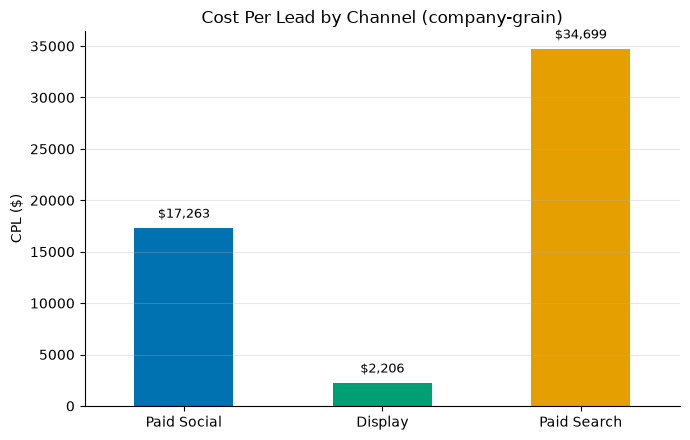

Lead-to-win rate by channel (%):
channel
Paid Social    44.1
Display        47.5
Paid Search    30.8
Name: count, dtype: float64


In [15]:
paid_channel_order_cpl = ['Paid Social', 'Display', 'Paid Search']

# Company-grain channel attribution, consistent with CAC's last-touch-to-close logic:
# - Closed-Won companies -> channel of their earliest winning lead (identical to earliest_won_cac above).
# - Not-yet-won companies -> channel of their most recent lead (last touch), since there's no closing lead.
crm_with_channel_cpl = crm_pipeline.assign(channel=crm_channel_cac)
not_won_mask_cpl = ~crm_with_channel_cpl.company_name.isin(earliest_won_cac.index)
last_touch_not_won_cpl = crm_with_channel_cpl[not_won_mask_cpl].sort_values('created_at').groupby('company_name').last()
company_channel_cpl = pd.concat([earliest_won_cac.channel, last_touch_not_won_cpl.channel])

companies_by_channel_cpl = company_channel_cpl.value_counts().reindex(channel_order_cac).fillna(0)
cpl_by_channel = (spend_by_channel_cac / companies_by_channel_cpl.reindex(paid_channel_order_cpl)).round(2)
lead_to_win_rate = (won_by_channel_cac.reindex(paid_channel_order_cpl) / companies_by_channel_cpl.reindex(paid_channel_order_cpl) * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4.5))
cpl_by_channel.plot(kind='bar', ax=ax, color=[channel_colors[c] for c in paid_channel_order_cpl])
ax.set_title('Cost Per Lead by Channel (company-grain)')
ax.set_ylabel('CPL ($)'); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=0)
ax.spines[['top', 'right']].set_visible(False); ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(cpl_by_channel): ax.text(i, v + max(cpl_by_channel) * 0.03, f'${v:,.0f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print('Lead-to-win rate by channel (%):'); print(lead_to_win_rate)

**Conclusion:** Display ($2,206/company) vs. Paid Social ($17,263) vs. Paid Search ($34,699, ~2x Paid Social) - now on a company-grain, last-touch-to-close basis consistent with CAC. Win rates diverge clearly (30.8-47.5%), unlike the earlier lead-grain read where they looked close (9-11%): Display leads (47.5%), Paid Social close behind (44.1%), and Paid Search trails on both cost and win rate (30.8%) - a double problem, not just a lead-cost one.

### Metric 5: Retention / Churn Rate
Reuses Metric 3's cohort retention computation as its own headline number — a distinct stakeholder question ("what's our churn rate") from LTV, even though the underlying data is identical.

In [16]:
print(f'Average quarterly retention rate (first full quarter post-close): {avg_q1_retention:.1%}')
print(f'Implied quarterly churn rate: {implied_quarterly_churn:.1%}')
print(f'Cohorts used: {list(period1_retention_clean.index.astype(str))} (2025Q4/2026Q1 excluded — too little post-close observation)')

Average quarterly retention rate (first full quarter post-close): 39.5%
Implied quarterly churn rate: 60.5%
Cohorts used: ['2025Q1', '2025Q2', '2025Q3'] (2025Q4/2026Q1 excluded — too little post-close observation)


**Conclusion: ~60.5% of Closed-Won companies churn within their first full quarter** (retention ~39.5%). Concentrated in Q1, then plateaus — the one fully-observed cohort holds flat at 33% for two more quarters after its first-quarter drop. Read as early-tenure churn, not steady-state. Same minor data quality caveat as Metric 3 applies (§3, Finding 3) — judged low-impact.

## 6. Exploratory Insights

Three findings, one per funnel stage, chosen specifically because each feeds directly into a Section 9 recommendation. Full exploratory work (paid-ads efficiency deep dives, first-touch-vs-eventual qualification, lead volume trends, full product-usage charts) is in the full notebook's §6.

### Acquisition — Paid Social absorbs the most spend, but is the least efficient

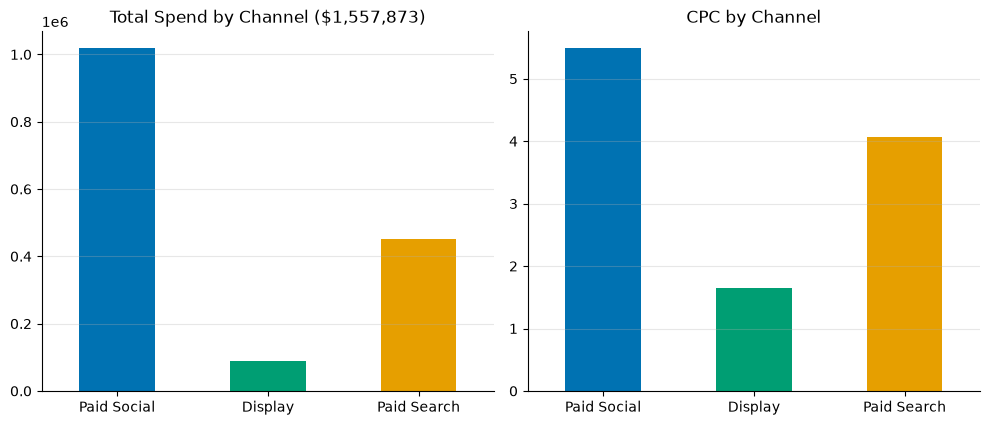

In [17]:
ads_order = ['Paid Social', 'Display', 'Paid Search']
ads_summary = paid_ads.groupby('channel').agg(spend=('cost', 'sum'), impressions=('impressions', 'sum'), clicks=('clicks', 'sum')).reindex(ads_order)
ads_summary['cpc'] = (ads_summary.spend / ads_summary.clicks).round(2)

colors = [channel_colors[c] for c in ads_order]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
ads_summary.spend.plot(kind='bar', ax=axes[0], color=colors, title=f'Total Spend by Channel (${ads_summary.spend.sum():,.0f})')
ads_summary.cpc.plot(kind='bar', ax=axes[1], color=colors, title='CPC by Channel')
for ax in axes:
    ax.set_xlabel(''); ax.tick_params(axis='x', rotation=0)
    ax.spines[['top', 'right']].set_visible(False); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

**Conclusion:** `Paid Social` absorbs 65% of the $1.56M total spend but has the *worst* CPC ($5.49). `Display` is cheapest by far ($1.65 CPC) despite the lowest CTR — this is exactly why Display looks efficient in Metrics 1/3/4, and exactly why Recommendation #3 (below) says don't trust that efficiency without an incrementality test — Display is a retargeting-style channel and our attribution is last-touch only, which structurally flatters it. Full attribution-bias discussion: full notebook §6.

### Conversion — Currently-open leads are ~3x older than deals that actually resolve

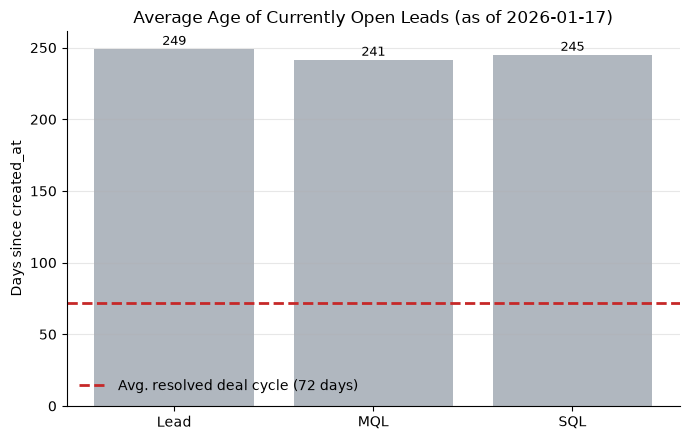

In [18]:
crm_pipeline['total_cycle_days'] = (crm_pipeline.close_date - crm_pipeline.created_at).dt.days
resolved_leads = crm_pipeline[crm_pipeline.close_status.notna()]
avg_resolved_cycle = resolved_leads.total_cycle_days.mean()

as_of_date = crm_pipeline.close_date.max()
open_leads = crm_pipeline[crm_pipeline.lifecycle_stage.isin(['Lead', 'MQL', 'SQL'])].copy()
open_leads['age_days'] = (as_of_date - open_leads.created_at).dt.days
age_by_stage = open_leads.groupby('lifecycle_stage').age_days.mean().reindex(['Lead', 'MQL', 'SQL'])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(age_by_stage.index, age_by_stage.values, color='#B0B7BF')
ax.axhline(avg_resolved_cycle, color='#C62828', linestyle='--', linewidth=2, label=f'Avg. resolved deal cycle ({avg_resolved_cycle:.0f} days)')
ax.set_title(f'Average Age of Currently Open Leads (as of {as_of_date.date()})')
ax.set_ylabel('Days since created_at')
ax.spines[['top', 'right']].set_visible(False); ax.grid(axis='y', alpha=0.3); ax.legend(frameon=False)
for i, v in enumerate(age_by_stage.values): ax.text(i, v + 3, f'{v:.0f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

**Conclusion — this is the actionable one.** Currently-open leads average **~240–250 days old**, roughly **3x** the ~72-day average cycle of deals that actually resolve. These aren't early-stage deals, they're past the point where a typical deal would already have closed one way or another. This informal finding is sharpened into a statistically rigorous 119-day threshold in §7 (Advanced Analysis), and drives Recommendation #1.

In [19]:
# company-grain win rate by entry channel (resolved deals only) — the channel win-rate context
# Recommendation #1 uses to prioritize dormant-company reactivation, computed here so it's traceable
resolved_companies = company_df[company_df.outcome.isin(['Closed Won', 'Closed Lost'])]
win_rate_by_entry_channel = (resolved_companies.outcome == 'Closed Won').groupby(resolved_companies.entry_channel).mean().reindex(channel_order).dropna()
print('Company-grain win rate by entry channel (Won / (Won+Lost), resolved companies only):')
print((win_rate_by_entry_channel * 100).round(1))

Company-grain win rate by entry channel (Won / (Won+Lost), resolved companies only):
entry_channel
Paid Social             51.9
Display                 64.0
Paid Search             55.6
Organic/Unattributed    50.0
Name: outcome, dtype: float64


**Conclusion:** at company grain, `Display`-originated companies win at **64.0%** once resolved, versus 55.6% (Paid Search), 51.9% (Paid Social), and 50.0% (Organic/Unattributed). This is the channel win-rate context Recommendation #1 uses alongside recency to prioritize dormant-company reactivation, in place of the propensity model's failed score.

### Retention — Quarterly cohort table (right-censoring caveat)

In [20]:
won = crm_pipeline[crm_pipeline.lifecycle_stage == 'Closed Won'].copy()
company_won = won.groupby('company_name').agg(close_date=('close_date', 'min'), company_ids=('company_id', list)).reset_index()
company_won['close_quarter'] = company_won.close_date.dt.to_period('Q')
cohort_sizes = company_won.groupby('close_quarter').company_name.nunique()

id_to_company = company_won.explode('company_ids').rename(columns={'company_ids': 'company_id'})[['company_id', 'company_name', 'close_quarter']]
usage_won = product_usage_events.merge(id_to_company, on='company_id')
usage_won['event_quarter'] = usage_won.event_time.dt.to_period('Q')
usage_won['period_number'] = usage_won.event_quarter.astype('int64') - usage_won.close_quarter.astype('int64')

active = usage_won.groupby(['close_quarter', 'period_number']).company_name.nunique().unstack()
retention = active.div(cohort_sizes, axis=0).round(2)
print('Retention table — share of each cohort active in period N (0 = close quarter):')
retention

Retention table — share of each cohort active in period N (0 = close quarter):


period_number,-1,0,1,2,3,4
close_quarter,,,,,,
2025Q1,NaN,1.00,0.33,0.33,0.33,0.17
2025Q2,0.77,0.77,0.32,0.18,NaN,NaN
2025Q3,0.60,0.93,0.53,NaN,NaN,NaN
2025Q4,0.88,0.88,0.25,NaN,NaN,NaN
2026Q1,1.00,NaN,NaN,NaN,NaN,NaN


**Conclusion:** 52 distinct Closed-Won companies (not 71 — 17 companies converted more than once under different lead records, corrected via `company_name` rollup). The 2025Q4/2026Q1 cohorts are right-censored (usage data only runs to mid-Jan 2026) — excluded from Metric 3/5's headline numbers, not shown as if they were real churn signal. Trustworthy, fully-observed transitions: 2025Q1→Q2 (33%), Q2→Q3 (32%), Q3→Q4 (53%) — the basis for the ~60.5% quarterly churn figure above.

## 7. Advanced Analysis (pointer only)

Beyond what's strictly needed to answer the brief, kept brief here on purpose — it demonstrates additional statistical/ML depth without repeating a full academic writeup. Two pieces, full code and reasoning in **full notebook §6**:

- **Kaplan-Meier survival analysis** (company-grain, 94 events / 26 censored): no company in this dataset has ever taken longer than **119 days** to close (S(119) ≈ 0.211, 95% CI [0.14, 0.29]). Applying that threshold, **21 of the 26 currently-open companies (81%) are statistically dormant**, not just "still in-flight" — this is the number behind Recommendation #1.
- **Propensity model** (statsmodels Logit for interpretability + cross-validated scikit-learn Random Forest for scoring): honestly **failed** — mean CV AUC **0.438**, below the 0.5 random-guessing baseline. No feature in this dataset (channel, lead count, trial engagement, distinct users) predicts deal outcome, most likely because the fields that would carry real signal (`amount`, `plan_tier`, `seats_used`) are effectively randomized in this synthetic dataset. Reported as a negative finding, not hidden — the dormant-reactivation ranking was still built end-to-end to demonstrate the workflow, but the write-up explicitly says not to trust it (Recommendation #1 uses recency + channel win-rate instead).


## 8. Data Model

**Methodology:** a full dbt-style lineage, layered from raw sources through staging (1:1 cleanup) → intermediate (business logic/joins, where Section 3's data-quality findings get encoded as reusable models) → a Type-2 snapshot for lifecycle history → surrogate-keyed dimensions → incremental facts → marts + a semantic-layer path. Reviewed against *Analytics Engineering with SQL and dbt* (Machado & Russa) for materialization and naming conventions. Full grain/materialization/incremental-strategy/test detail for all ~27 models: **full notebook §7** and the published interactive artifact (`deskbird_data_model.html`).

### Sources
Raw data as it lands, before any dbt transformation. Ad platforms are modeled as 3 separate sources (realistic — each platform's export lands separately in production), not the single pre-unioned CSV we actually received.
- `src_google_ads`, `src_linkedin_ads`, `src_display_network` — one row per campaign per day each
- `src_crm_pipeline` — one row per lead
- `src_product_usage_events` — one row per event

### Staging
1:1 with source — renaming, type-casting, light cleanup only, no joins/aggregation. Materialized as **views**.
- `stg_google_ads` / `stg_linkedin_ads` / `stg_display_network` — cleaned ad spend
- `stg_crm_pipeline` — cleaned CRM leads
- `stg_product_usage_events` — cleaned usage events; `plan_tier`/`seats_used` kept as raw passthrough here, resolved properly downstream rather than dropped

### Intermediate
Business logic and joins — where Section 3's findings become reusable models instead of re-derived logic. Materialized as **ephemeral** (inlined CTEs).
- `int_paid_ads_unioned` — unions the 3 ad sources
- `int_crm_identity_resolved` — collapses lead-grain `company_id` down to real `company_name` accounts (the single most important model in the project)
- `int_trial_windows` — extracts each lead's trial start/end
- `int_crm_channel_attribution` — joins `campaign_id` → `channel`, buckets nulls as Organic/Unattributed
- `int_usage_events_in_trial` — filters usage events to in-trial-window only, preventing post-close leakage
- `int_company_plan_tier_resolved` — mode-resolves the noisy per-event `plan_tier` into one company-level value with a confidence score, rather than trusting or discarding it raw

### Snapshot (SCD Type 2)
- `snap_crm_lead_lifecycle` — tracks `lifecycle_stage` transitions over time, sourced directly from `stg_crm_pipeline` (not a cleaned/joined model — `lead_id` is already a clean key at that grain)

### Dimensions
All keyed with `sk_*` surrogate keys (`dbt_utils.generate_surrogate_key()`) — facts join on these, not fragile natural keys like `company_name`.
- `dim_companies`, `dim_campaigns`, `dim_users` — Type 1
- `dim_leads` — Type 2, built on the snapshot above

### Facts
Incremental strategy chosen per how the underlying data actually changes: `fct_leads` (merge — lifecycle stage gets updated), `fct_usage_events` (append — immutable event log), `fct_ad_spend_daily` (merge — platforms revise recent days), `fct_company_seats_daily` (insert_overwrite — daily snapshot).

### Marts + Semantic Layer
`mart_growth_metrics_by_channel`, `mart_cohort_retention`, `mart_dormant_scoring` — physical marts proving the 5 metrics compute correctly. A MetricFlow semantic-layer path sits alongside these as the target architecture (the hosted serving layer is a dbt Cloud feature, not available in dbt-core alone).

### Testing philosophy
Every severity call traces back to something actually measured in Section 3. **Error-level** (build-blocking): referential integrity, `unique`/`not_null` on every key, `accepted_values` on categorical fields, hard date-ordering invariants with zero observed violations. **Warning-level** (logged, not blocking): the one date-ordering check that does fail (6 known rows), the `plan_tier` consistency check (expected to fail often — it's monitoring noise, not enforcing a clean invariant), and every mart-level caveat (small-n, censored cohorts, non-predictive propensity score) — real limitations surfaced as monitored warnings, not hidden behind a passing test suite.

![dbt data model diagram](data_model_diagram.png)


## 9. Recommendations

Every recommendation traces back to a specific finding already shown above — nothing new introduced here.

### Sales & CRM Process

#### 1. Split the 119-day cutoff into two tracks: disqualify from active pipeline, but route into a separate reactivation motion

*(High confidence on the cutoff itself and on not using the propensity score; lower confidence on the reactivation ranking below)*

No company in this dataset has ever taken longer than 119 days (from most recent contact) to close — 21 of the 26 currently-open companies are already past that point. **"Disqualify"** means removing them from active sales pipeline tracking; **"reactivate"** means routing them into a separate, lower-touch win-back motion — two halves of one process, which is why we called this segment "Dormant" rather than "Dead." The propensity model built to rank these for reactivation came back with no usable signal (CV AUC 0.44, below random chance) once honestly tested — prioritize instead with the two validated signals: most-recently-engaged first, and channel win-rate context (Display 64% vs. 50–56% elsewhere).

#### 2. Standardize how `amount` gets entered into the CRM

`amount` behaves as a deal-stage estimate that varies deal-to-deal for the same company, not a stable, size-driven contract value — it doesn't correlate with seat count either. This limited how precisely LTV could be built. Recommend tightening CRM data-entry discipline, or better, integrating actual billing-system data as the LTV input.

### Marketing & Acquisition

#### 3. Do not shift budget toward Display without an incrementality test first

*(High confidence on the caveat; the underlying efficiency numbers themselves are less trustworthy)*

Display leads on nearly every acquisition metric computed here, but it's a retargeting-style channel and our attribution is last-touch only — it very plausibly gets credited for conversions Paid Social/Search actually originated upstream. This is a structural, expected bias, not just an unmeasured risk. Recommend a geo-lift holdout test or multi-touch attribution model before reallocating spend on these numbers alone.

#### 4. Fix Paid Search's cost problem at the bidding/placement level, not the targeting level

Paid Search's expensive CAC ($112,771) is driven almost entirely by lead cost ($10,252/lead, 2.5x Paid Social), not lead quality — its win rate (9.1%) is close to Paid Social's (10.3%). The fix is cheaper bidding/placements, not better audience targeting.

### Retention

#### 5. Invest retention effort in the first quarter post-close, specifically

~60.5% of Closed-Won companies churn within their first full quarter — but the one fully-observed cohort shows churn concentrating there and then plateauing. First-quarter onboarding/engagement has the highest leverage of any point in the retention curve.

#### 6. Revisit the churn/LTV numbers once 1–2 more quarters of data reduce censoring

Both LTV:CAC and churn rest on a single fully-observed cohort (2025 Q1, n=6) and a constant-churn assumption the data only partially supports. Treat the current blended LTV:CAC (0.27) and churn rate (60.5%) as directional first-pass benchmarks, not final unit economics.

### Product & Onboarding Strategy

#### 7. Reconsider the 14-day free trial — a discounted first quarter may convert and retain better

*(Strategic, not directly testable in this dataset — a genuine data limitation itself)*

deskbird is an employee-facing workplace app, not a single-user tool — real adoption requires habit formation across a whole team, and 14 days is a short window for that, let alone for the product's full value to become visible before the buying decision gets made. This plausibly caps the 43.3% overall win rate (Metric 2) below what it could be. Candidate change worth piloting: replace the free 14-day trial with a discounted first quarter (e.g. 50% off) rather than a hard free/paid cutoff — buys the customer's team more real adoption time, creates space for an active Customer Success engagement loop during that window, and once a company is paying anything at all, switching-cost inertia works in our favor. A hypothesis to pilot, not something this dataset can prove.

### Data Infrastructure

#### 8. Formalize the data-quality checks as ongoing production monitors, not one-time analysis

The chronological-order and trial-length validations should run continuously (dbt tests or a scheduled job), so issues like the 6 close-date anomalies get caught automatically going forward.

#### 9. To make propensity/lead-scoring modeling actually viable, the underlying data needs to get richer

The propensity model was properly validated and honestly failed — no available feature carries real predictive signal. That's a data-availability problem, not a modeling one: real firmographic data (company size, industry, budget authority) and CRM activity logs would be the natural next fields to capture.

**If we had to pick the two highest-leverage actions:** (1) the 119-day dormant-lead disqualification/reactivation process — the most statistically solid, immediately actionable finding in the whole analysis, and (2) the Display incrementality test — because right now the data is actively pointing budget in a direction we can't fully trust.

---

*Full derivations, all 8 data-quality checks, complete exploratory analysis, and the fully-enumerated data model (grain/materialization/tests for all ~27 models): `deskbird_growth_analysis.ipynb`.*